In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.applications import resnet50, mobilenet_v2, efficientnet
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import pandas as pd
import seaborn as sns



c:\Users\S.Lefakis\AppData\Local\anaconda3\envs\NeuralNetworks\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
df = pd.read_csv(r"C:\Users\S.Lefakis\Downloads\energy_utilities_sim.csv")


print(df.shape)
print(df.info())
print(df.describe(include="all").T)

(1253, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1253 entries, 0 to 1252
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        1253 non-null   int64  
 1   average_daily_consumption      1253 non-null   float64
 2   average_days_to_bill_payment   1253 non-null   float64
 3   customer_since                 1253 non-null   str    
 4   area                           1253 non-null   float64
 5   age                            1253 non-null   str    
 6   marital_status                 1253 non-null   str    
 7   educational_level              1253 non-null   str    
 8   prefecture                     1253 non-null   str    
 9   average_monthly_visits         1253 non-null   float64
 10  average_web_monthly_visits     1253 non-null   float64
 11  average_mobile_monthly_visits  1253 non-null   float64
dtypes: float64(6), int64(1), str(5)
memory usage: 11

In [3]:

df["customer_since"] = pd.to_datetime(df["customer_since"], errors="coerce")


df["customer_since_year"] = df["customer_since"].dt.year
df["customer_since_month"] = df["customer_since"].dt.month
df["customer_since_month_name"] = df["customer_since"].dt.month_name()
df["customer_since_quarter"] = df["customer_since"].dt.quarter

reference_date = pd.Timestamp("2018-01-01")

df["customer_tenure_years"] = (
    (reference_date - df["customer_since"]).dt.days / 365.25
)
print(df[[
    "customer_since",
    "customer_since_year",
    "customer_since_month",
    "customer_since_quarter",
    "customer_tenure_years"
]].head())

  customer_since  customer_since_year  customer_since_month  \
0     2015-05-14                 2015                     5   
1     2015-06-02                 2015                     6   
2     2015-06-29                 2015                     6   
3     2015-03-19                 2015                     3   
4     2014-08-22                 2014                     8   

   customer_since_quarter  customer_tenure_years  
0                       2               2.636550  
1                       2               2.584531  
2                       2               2.510609  
3                       1               2.789870  
4                       3               3.362081  


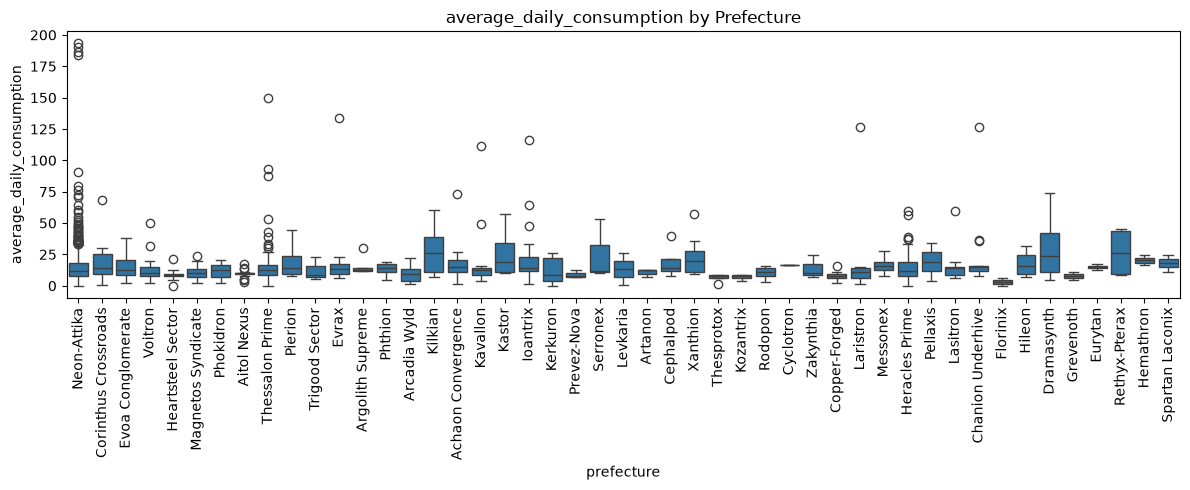

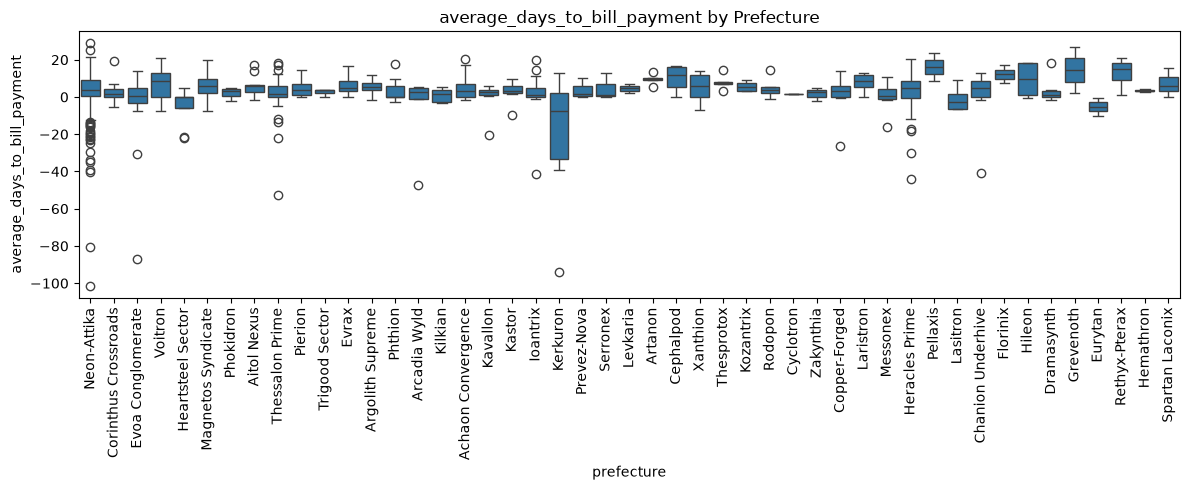

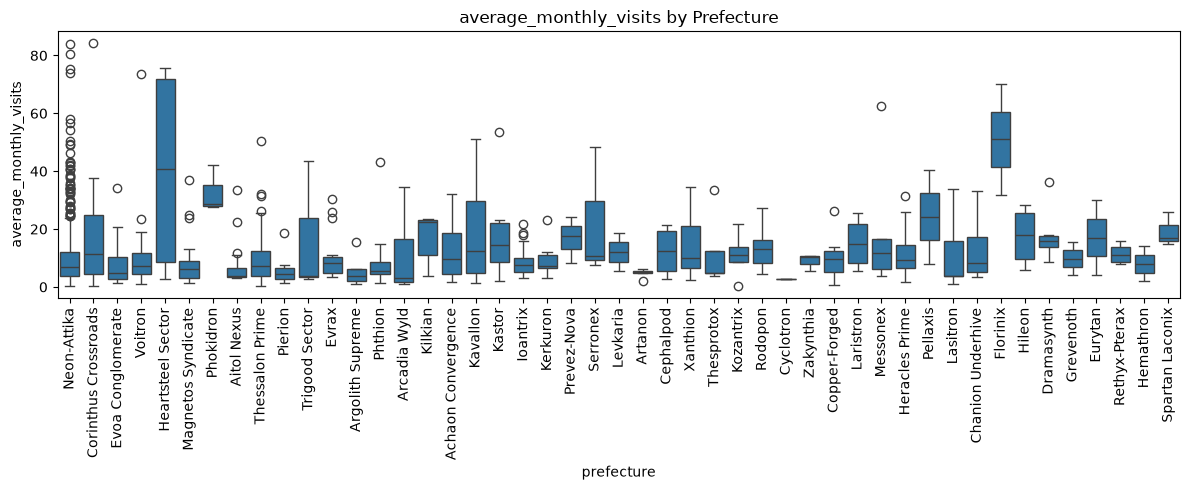

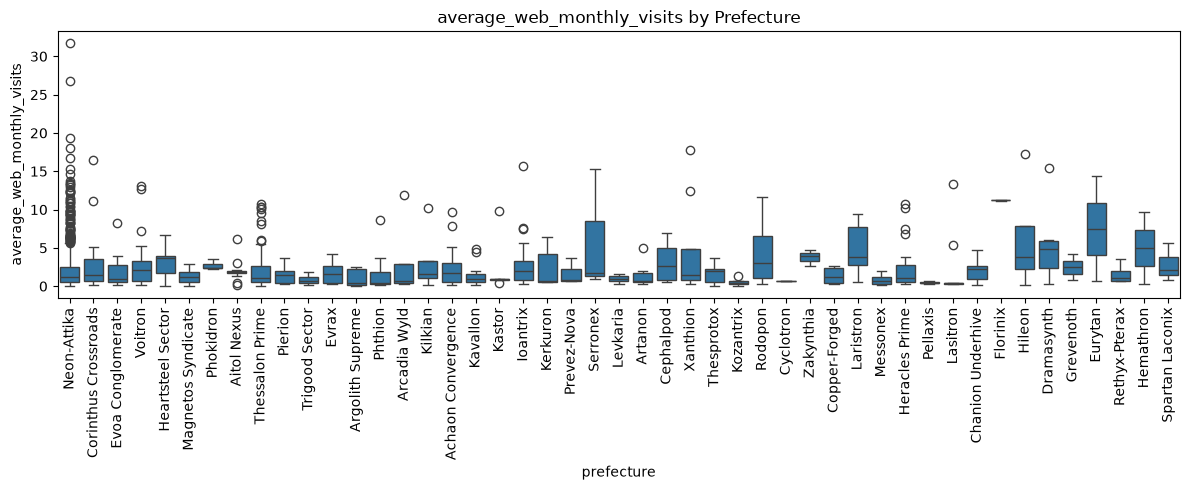

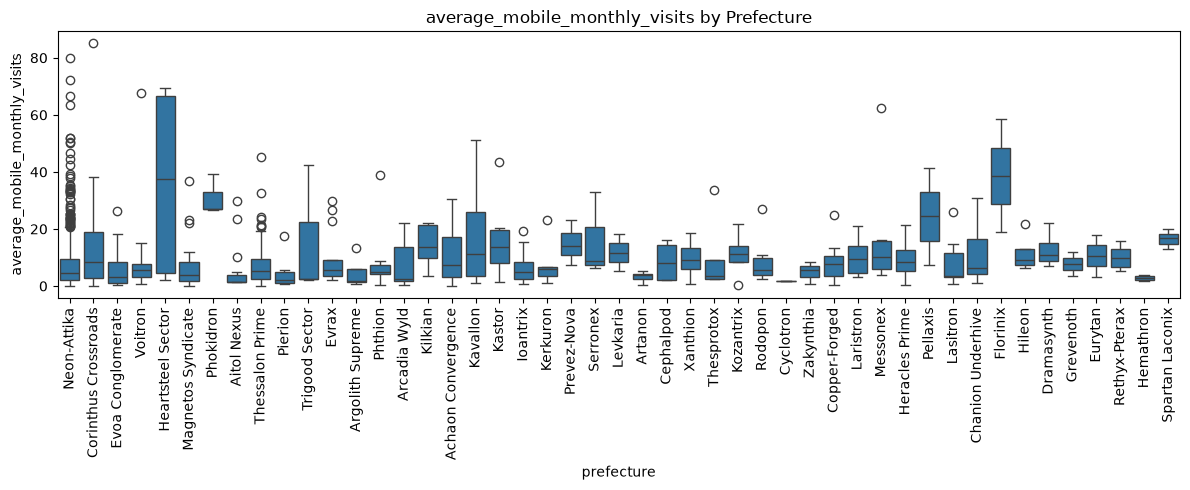

In [5]:
metrics = [
    "average_daily_consumption",
    "average_days_to_bill_payment",
    "average_monthly_visits",
    "average_web_monthly_visits",
    "average_mobile_monthly_visits"
]

for metric in metrics:

    plt.figure(figsize=(12, 5))

    sns.boxplot(
        data=df,
        x="prefecture",
        y=metric
    )

    plt.title(f"{metric} by Prefecture")
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

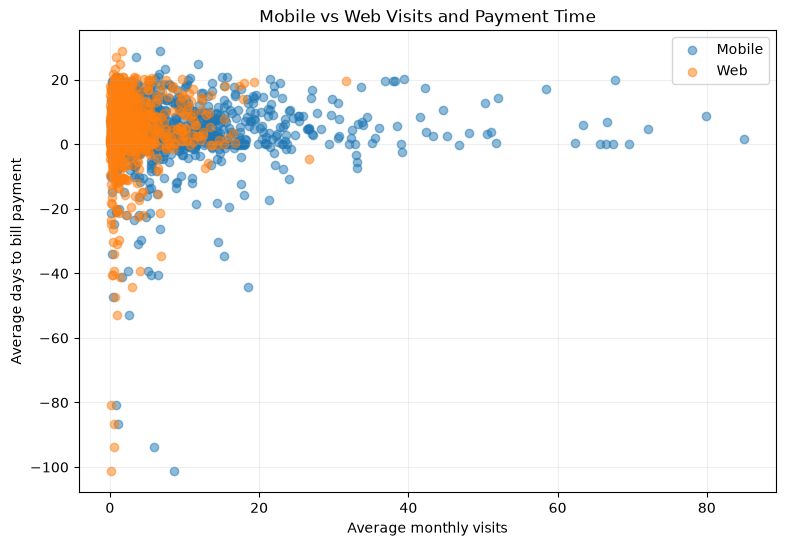

In [6]:


plt.figure(figsize=(9, 6))

plt.scatter(
    df["average_mobile_monthly_visits"],
    df["average_days_to_bill_payment"],
    alpha=0.5,
    label="Mobile"
)

plt.scatter(
    df["average_web_monthly_visits"],
    df["average_days_to_bill_payment"],
    alpha=0.5,
    label="Web"
)

plt.xlabel("Average monthly visits")
plt.ylabel("Average days to bill payment")
plt.title("Mobile vs Web Visits and Payment Time")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

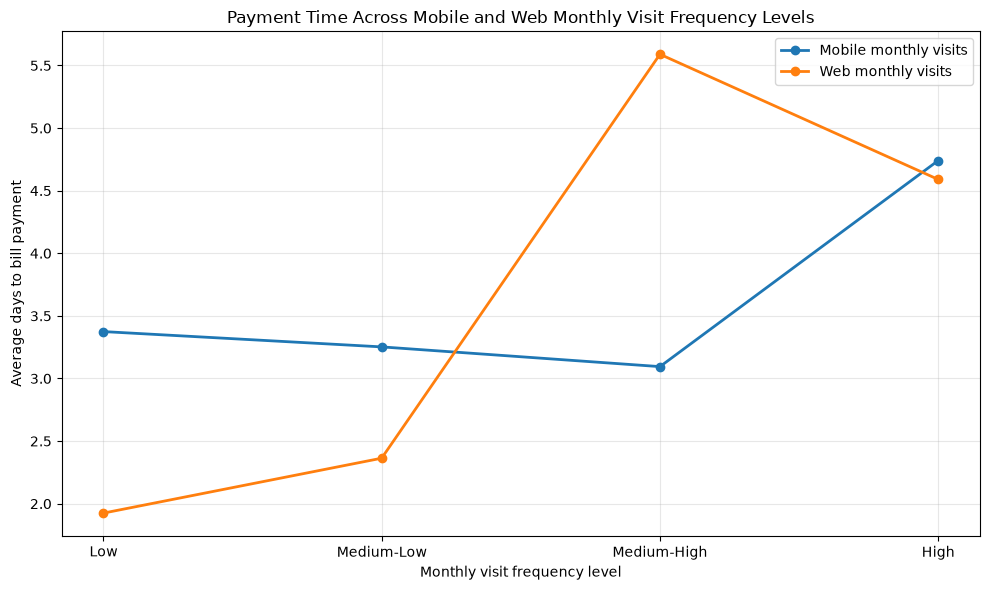

In [7]:


# Create temporary quartile groups
mobile_bins = pd.qcut(
    df["average_mobile_monthly_visits"],
    q=4,
    duplicates="drop"
)

web_bins = pd.qcut(
    df["average_web_monthly_visits"],
    q=4,
    duplicates="drop"
)

# Calculate average payment time for each visit-frequency group
mobile_avg = df.groupby(
    mobile_bins, observed=True
)["average_days_to_bill_payment"].mean()

web_avg = df.groupby(
    web_bins, observed=True
)["average_days_to_bill_payment"].mean()

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    range(len(mobile_avg)),
    mobile_avg.values,
    marker="o",
    linewidth=2,
    label="Mobile monthly visits"
)

plt.plot(
    range(len(web_avg)),
    web_avg.values,
    marker="o",
    linewidth=2,
    label="Web monthly visits"
)

plt.xticks(
    range(4),
    ["Low", "Medium-Low", "Medium-High", "High"]
)

plt.xlabel("Monthly visit frequency level")
plt.ylabel("Average days to bill payment")
plt.title("Payment Time Across Mobile and Web Monthly Visit Frequency Levels")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\S.Lefakis\AppData\Local\Temp\ipykernel_27732\2763882106.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


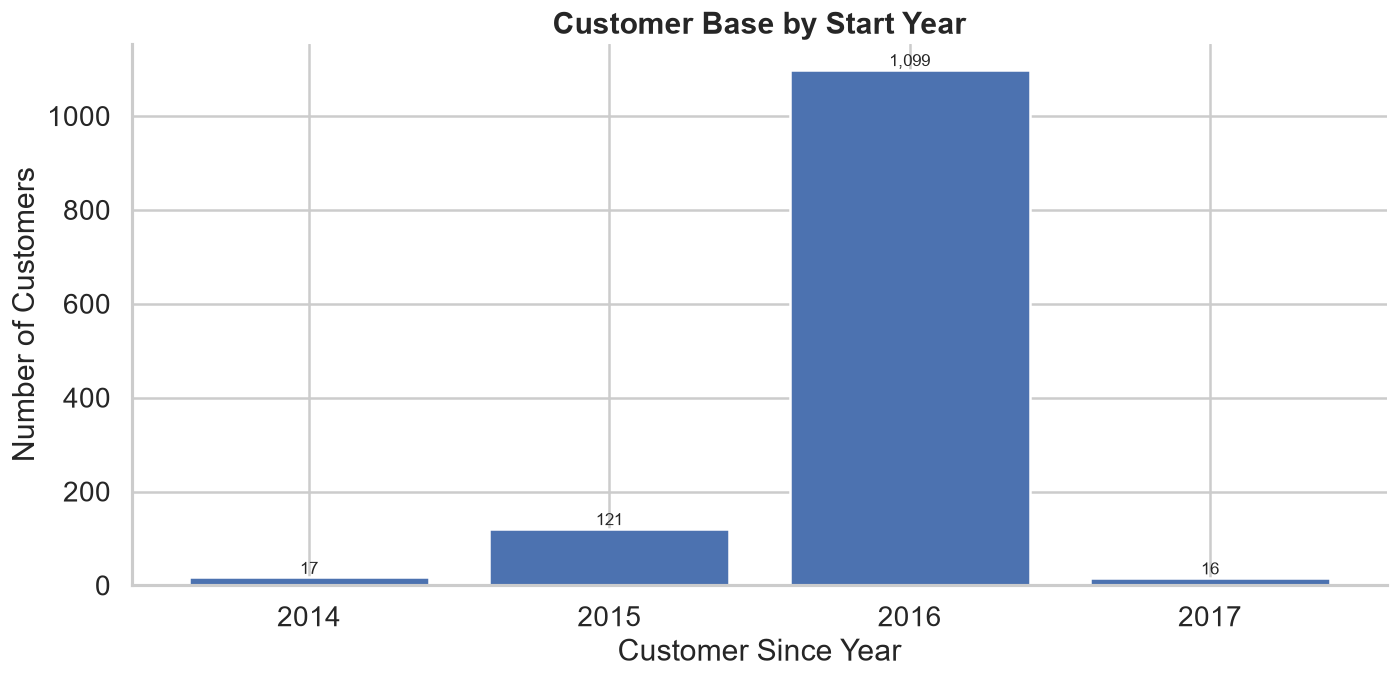

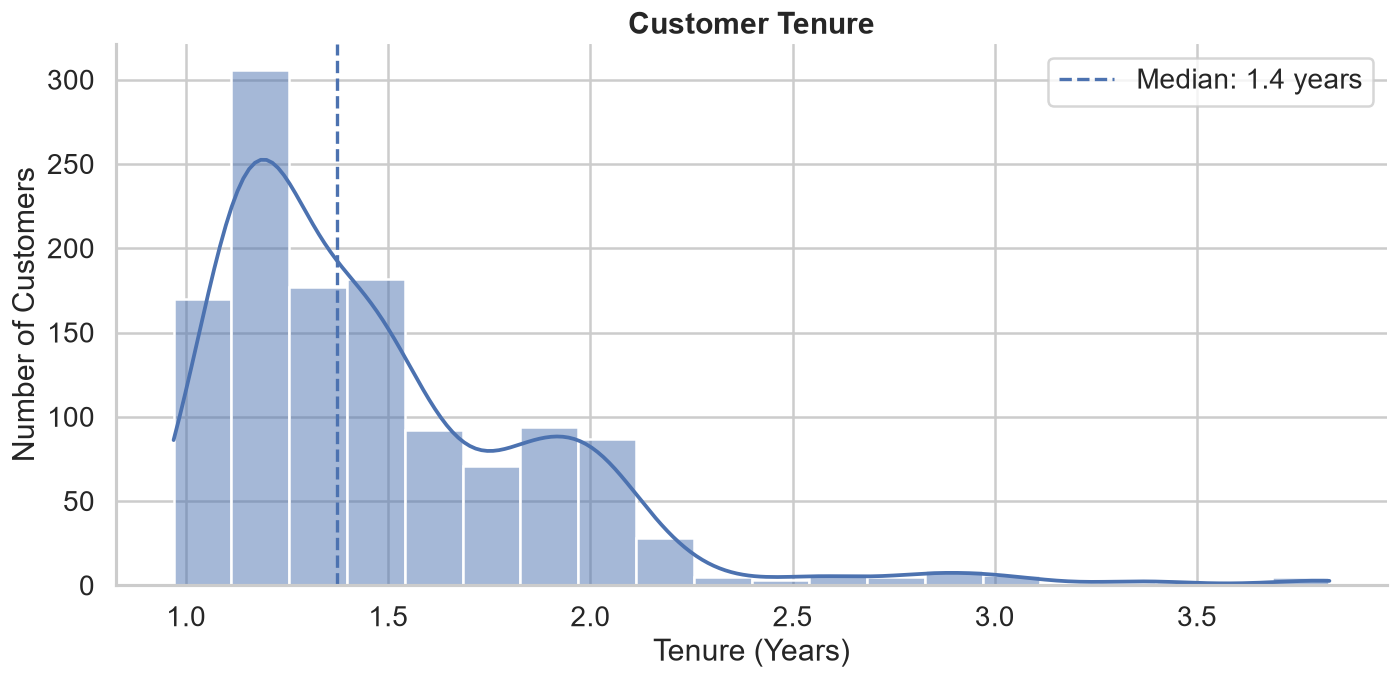

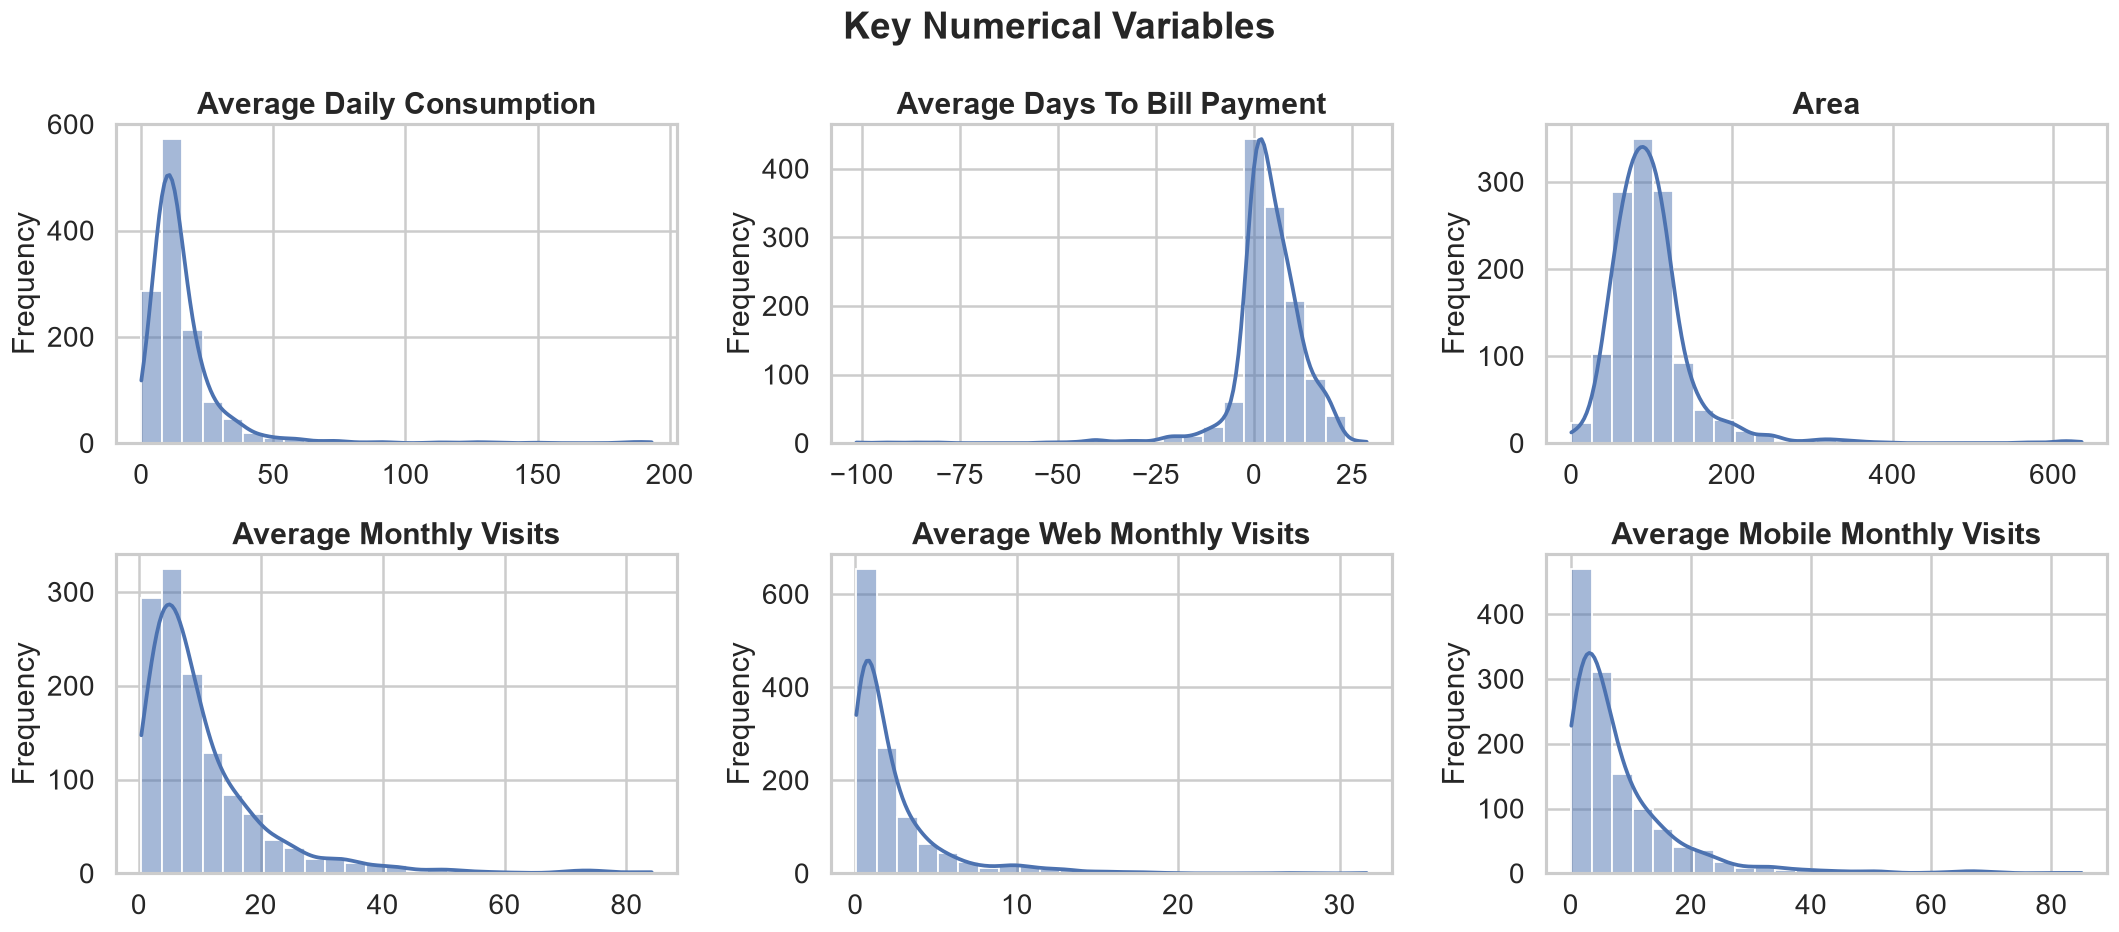

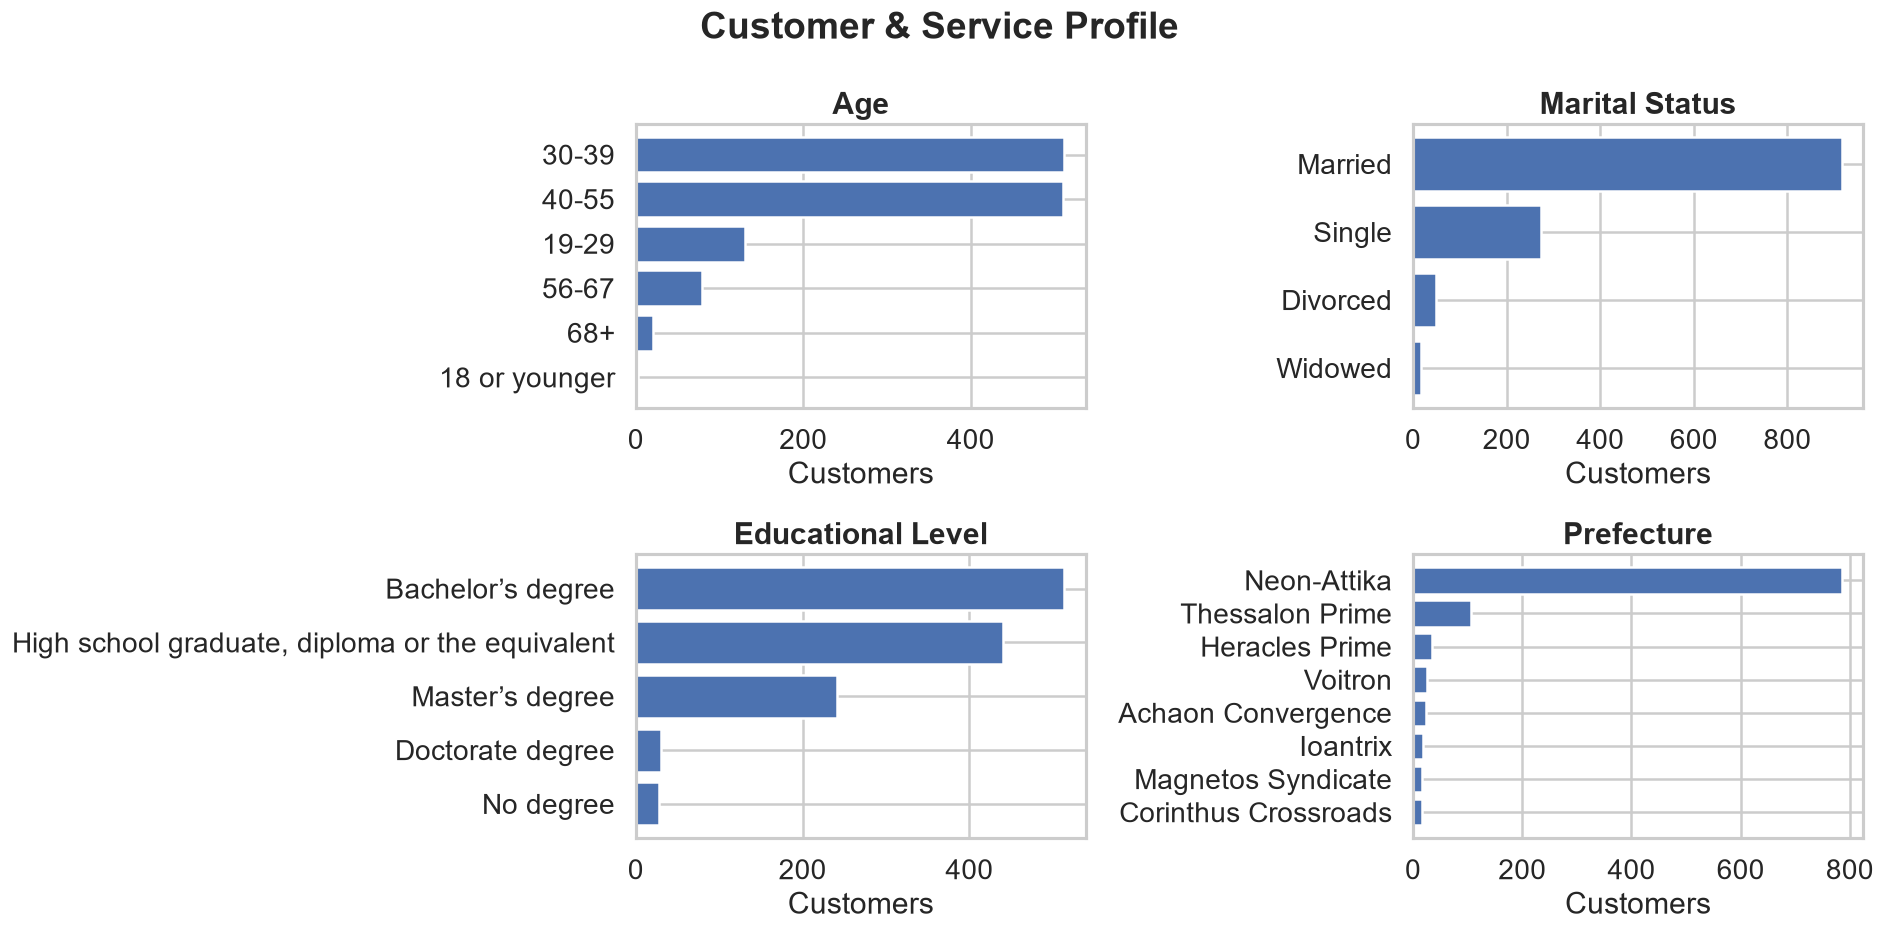

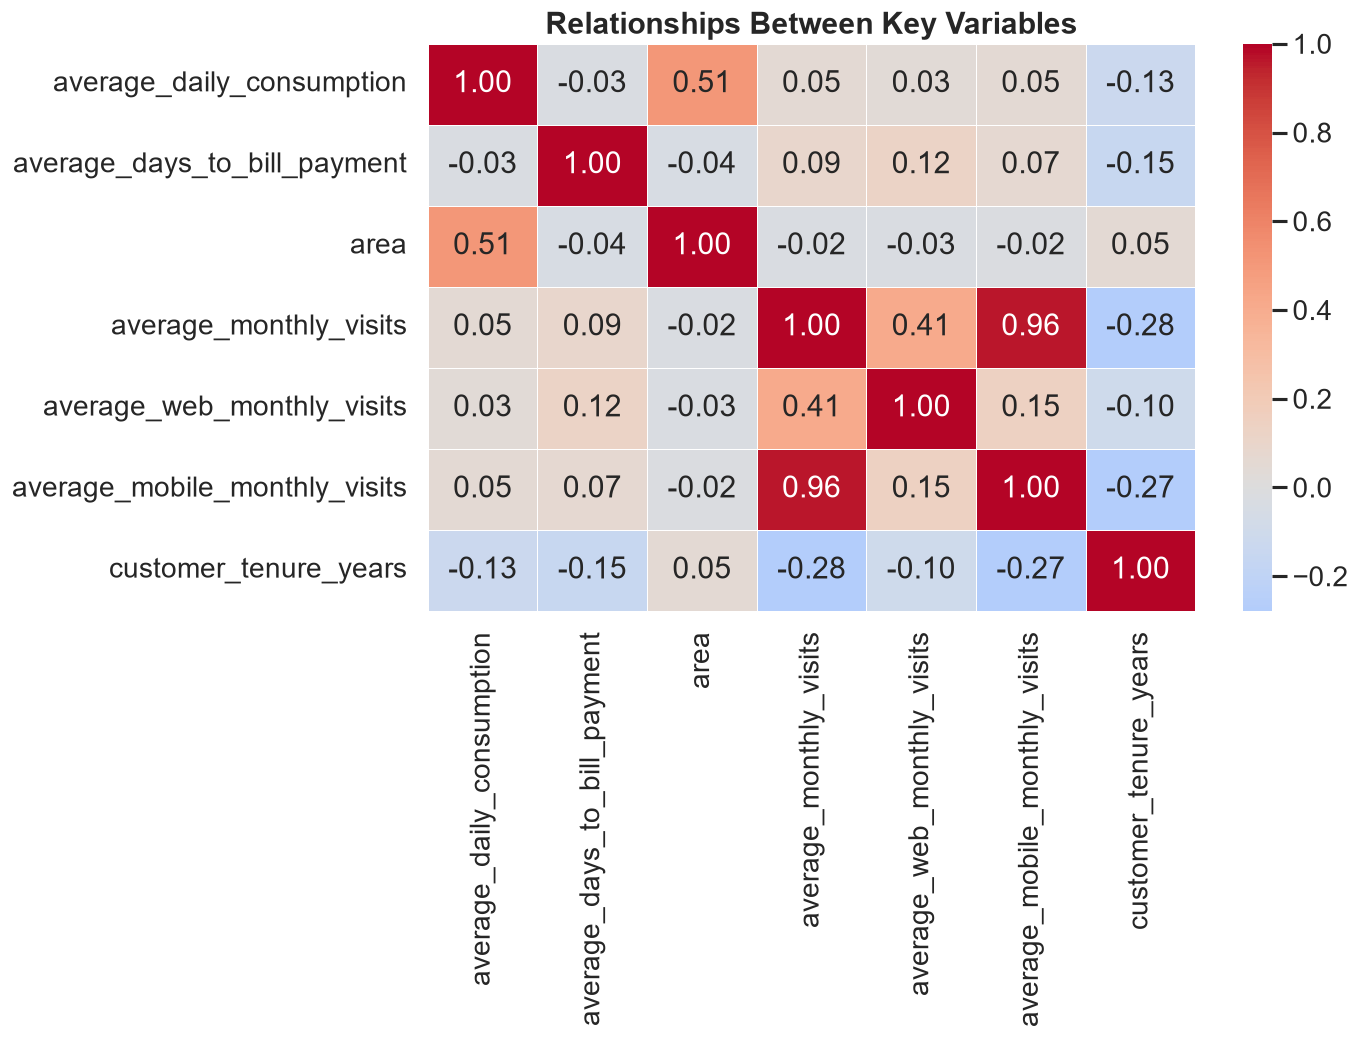

In [ ]:


numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

id_cols = [
    c for c in df.columns
    if any(x in c.lower() for x in [
        "id", "identifier", "uuid",
        "account_number", "customer_number"
    ])
]

exclude_numeric = id_cols + [
    "customer_since_year",
    "customer_since_month",
    "customer_since_quarter"
]

analysis_numeric_cols = [
    c for c in numeric_cols
    if c not in exclude_numeric
]

# PowerPoint style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300



counts = df["customer_since_year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    counts.index.astype(str),
    counts.values
)

ax.set_title("Customer Base by Start Year", fontweight="bold")
ax.set_xlabel("Customer Since Year")
ax.set_ylabel("Number of Customers")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

sns.despine()
plt.tight_layout()
plt.show()




fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    df["customer_tenure_years"].dropna(),
    bins=20,
    kde=True,
    ax=ax
)

median = df["customer_tenure_years"].median()

ax.axvline(
    median,
    linestyle="--",
    linewidth=2,
    label=f"Median: {median:.1f} years"
)

ax.set_title("Customer Tenure", fontweight="bold")
ax.set_xlabel("Tenure (Years)")
ax.set_ylabel("Number of Customers")
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()



cols = analysis_numeric_cols[:6]

fig, axes = plt.subplots(
    int(np.ceil(len(cols) / 3)),
    3,
    figsize=(18, 8)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cols):
    sns.histplot(
        df[col].dropna(),
        bins=25,
        kde=True,
        ax=ax
    )
    ax.set_title(
        col.replace("_", " ").title()
    )
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

for ax in axes[len(cols):]:
    fig.delaxes(ax)

fig.suptitle(
    "Key Numerical Variables",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()



cols = [
    c for c in categorical_cols
    if c != "customer_since"
][:4]

fig, axes = plt.subplots(
    int(np.ceil(len(cols) / 2)),
    2,
    figsize=(16, 8)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cols):

    counts = (
        df[col]
        .value_counts()
        .head(8)
        .sort_values()
    )

    ax.barh(
        counts.index.astype(str),
        counts.values
    )

    ax.set_title(
        col.replace("_", " ").title()
    )

    ax.set_xlabel("Customers")
    ax.set_ylabel("")

for ax in axes[len(cols):]:
    fig.delaxes(ax)

fig.suptitle(
    "Customer & Service Profile",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()



corr = df[analysis_numeric_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=.5
)

plt.title(
    "Relationships Between Key Variables",
    fontweight="bold"
)

plt.tight_layout()
plt.show()


